<a href="https://colab.research.google.com/github/yashdeepspodder23/BlackHoleSimulations/blob/main/BHSim6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_6954/2532886710.py:149: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  remnant_horizon = plt.Circle(bh_pos_center, 0.0, color='black', edgecolor='orange', lw=2, fill=True, zorder=3.5, alpha=0.0)


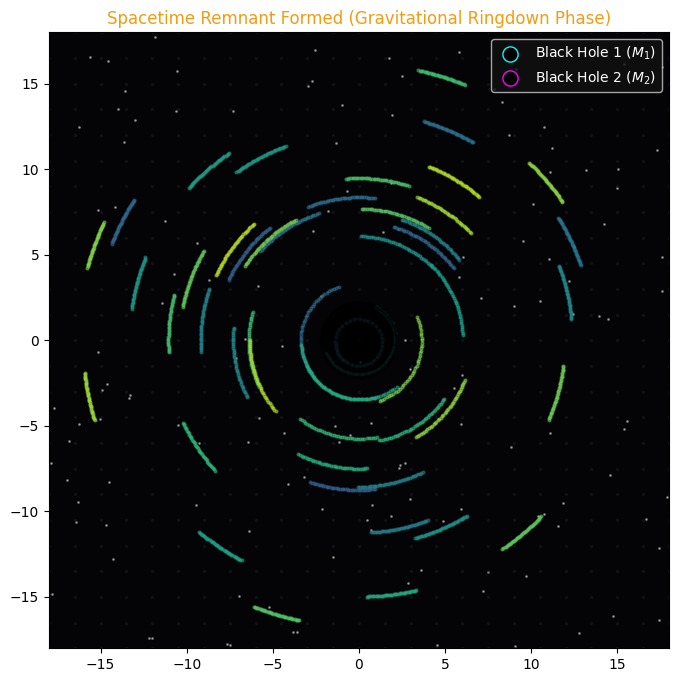

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import collections

# =====================================================================
# NUMERICAL RELATIVITY BINARY PARAMETERS
# =====================================================================
G = 1         # Gravitational constant
M1 = 10.0      # Mass of Black Hole 1
M2 = 5.0      # Mass of Black Hole 2
M_total = M1 + M2
dt = 0.075     # Numerical time slice increment

num_p = 50    # Number of tracer accretion particles
np.random.seed(123)

# Initialize Accretion Disk Tracer Particles around the binary system
poss = np.random.uniform(-15, 15, (num_p, 2))
vel = np.zeros((num_p, 2))
# Give particles initial velocity to form a dynamic disk
for i in range(num_p):
    r = np.linalg.norm(poss[i])
    if r > 0:
        # Keplerian-like initial velocity mapping
        v_mag = np.sqrt(G * M_total / r)
        vel[i, 0] = -v_mag * (poss[i, 1] / r)
        vel[i, 1] = v_mag * (poss[i, 0] / r)

# Global variables for trail tracking
trail_length = 40
trail_data = [collections.deque(maxlen=trail_length) for _ in range(num_p)]
bh1_trail = collections.deque(maxlen=100)
bh2_trail = collections.deque(maxlen=100)

# Initialize Binary Black Hole Orbit Parameters
# In Numerical Relativity, gravitational radiation causes the orbit to decay
r_binary_init = 8.0  # Initial separation
omega = np.sqrt(G * M_total / r_binary_init**3) # Initial angular velocity
phi_binary = 0.0
r_binary = r_binary_init
merged = False
merge_frame = None

# =====================================================================
# DYNAMIC SPACETIME & COALESCENCE PHYSICS ENGINE
# =====================================================================
def update_system(poss, vel, r_binary, phi_binary, frame):
    global merged, merge_frame

    # 1. EVOLVE THE BLACK HOLE BINARY (Numerical Relativity Decay Model)
    if not merged:
        # Energy loss via Gravitational Waves (Quadrupole Formula derivation): dr/dt proportional to -1/r^3
        dr_dt = - (64.0 / 5.0) * (G**3 * M1 * M2 * M_total) / (r_binary**3)
        r_binary += dr_dt * dt

        # Kepler's third law updates as the orbital separation shrinks
        omega = np.sqrt(G * M_total / r_binary**3)
        phi_binary += omega * dt

        # Compute individual positions relative to center of mass
        bh1_pos = np.array([ (M2/M_total)*r_binary*np.cos(phi_binary),  (M2/M_total)*r_binary*np.sin(phi_binary)])
        bh2_pos = np.array([-(M1/M_total)*r_binary*np.cos(phi_binary), -(M1/M_total)*r_binary*np.sin(phi_binary)])

        # Check for event horizon contact/merger
        Rs_total = 2.0 * G * M_total
        if r_binary <= Rs_total * 0.4:
            merged = True
            merge_frame = frame
    else:
        # Post-merger: The singularities have fused into a single spinning remnant at the center
        bh1_pos = np.array([0.0, 0.0])
        bh2_pos = np.array([0.0, 0.0])

    # 2. EVOLVE THE TRACER PARTICLES IN THE DYNAMIC METRIC
    for i in range(num_p):
        if merged:
            # Gravity field transitions smoothly to a single central mass
            r_vec = bh_pos_center - poss[i]
            r = np.linalg.norm(r_vec)
            if r < 1.2: # Falling below final horizon
                poss[i] = np.array([0.0, 0.0])
                vel[i] = np.array([0.0, 0.0])
                continue
            f_mag = (G * M_total) / r**2
            f = f_mag * (r_vec / r)
        else:
            # Pre-merger: Particles experience a dynamic, changing gravitational field
            r1_vec = bh1_pos - poss[i]
            r2_vec = bh2_pos - poss[i]
            r1 = np.linalg.norm(r1_vec)
            r2 = np.linalg.norm(r2_vec)

            # Singularity capture shields
            if r1 < 0.6 or r2 < 0.6:
                poss[i] = np.array([0.0, 0.0])
                vel[i] = np.array([0.0, 0.0])
                continue

            # Superposition of gravitational forces
            f1 = ((G * M1) / r1**2) * (r1_vec / r1)
            f2 = ((G * M2) / r2**2) * (r2_vec / r2)
            f = f1 + f2

            # Numerical Relativity Correction: Model the metric stretching (gravitational wave strain)
            # This applies a small spatial modulation based on the binary's orientation
            strain_factor = 0.15 * (r_binary_init / r_binary)**0.5
            wave_mod = 1.0 + strain_factor * np.cos(2.0 * phi_binary - np.arctan2(poss[i,1], poss[i,0]))
            f *= wave_mod

        # Standard integration updates
        vel[i] += f * dt
        poss[i] += vel[i] * dt

    return poss, vel, r_binary, phi_binary, bh1_pos, bh2_pos

# =====================================================================
# GRAPHICS AND GRAPH RENDERING LAYOUT
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-18, 18)
ax.set_ylim(-18, 18)
ax.set_facecolor('#040406')

# Static stars
num_stars = 150
ax.scatter(np.random.uniform(-18, 18, num_stars), np.random.uniform(-18, 18, num_stars), s=1, color='white', alpha=0.4, zorder=0)

# Plot objects for the two separate black holes
bh1_plot = ax.scatter([], [], color='black', edgecolors='cyan', s=120, zorder=4, label='Black Hole 1 ($M_1$)')
bh2_plot = ax.scatter([], [], color='black', edgecolors='magenta', s=120, zorder=4, label='Black Hole 2 ($M_2$)')

bh1_line, = ax.plot([], [], color='cyan', linestyle='-', lw=1, alpha=0.4, zorder=2)
bh2_line, = ax.plot([], [], color='magenta', linestyle='-', lw=1, alpha=0.4, zorder=2)

# Dynamic Space Deformation Grid Overlay (Simulating spacetime curvature)
grid_res = 25
gx, gy = np.meshgrid(np.linspace(-18, 18, grid_res), np.linspace(-18, 18, grid_res))
grid_plot = ax.scatter(gx, gy, color='#1f2833', s=2, alpha=0.3, zorder=1)

# Particle trails setup
particles_trails = []
colors = plt.cm.viridis(np.linspace(0.3, 0.9, num_p))
for i in range(num_p):
    line, = ax.plot([], [], 'o:', color=colors[i], markersize=2, alpha=0.5, zorder=3)
    particles_trails.append(line)

bh_pos_center = np.array([0, 0])
remnant_horizon = plt.Circle(bh_pos_center, 0.0, color='black', edgecolor='orange', lw=2, fill=True, zorder=3.5, alpha=0.0)
ax.add_patch(remnant_horizon)

ax.legend(loc='upper right', facecolor='#111111', labelcolor='white')
title_text = ax.set_title('Binary Black Hole Coalescence (Numerical Relativity Model)', color='white')

# =====================================================================
# ANIMATION RENDERING LOOP
# =====================================================================
def init():
    for line in particles_trails:
        line.set_data([], [])
    bh1_line.set_data([], [])
    bh2_line.set_data([], [])
    return particles_trails + [bh1_plot, bh2_plot, bh1_line, bh2_line]

def animate(frame):
    global poss, vel, r_binary, phi_binary

    poss, vel, r_binary, phi_binary, bh1_p, bh2_p = update_system(poss, vel, r_binary, phi_binary, frame)

    if not merged:
        bh1_plot.set_offsets(bh1_p)
        bh2_plot.set_offsets(bh2_p)
        bh1_trail.append(bh1_p.copy())
        bh2_trail.append(bh2_p.copy())

        # Draw orbital paths showing the spiral cascade
        bh1_line.set_data([p[0] for p in bh1_trail], [p[1] for p in bh1_trail])
        bh2_line.set_data([p[0] for p in bh2_trail], [p[1] for p in bh2_trail])
    else:
        # Smoothly expand and flash the final Event Horizon during final merger ringdown
        bh1_plot.set_offsets([50, 50]) # Hide off screen
        bh2_plot.set_offsets([50, 50])
        bh1_line.set_data([], [])
        bh2_line.set_data([], [])

        remnant_horizon.set_radius(2.2)
        remnant_horizon.set_alpha(0.8)
        title_text.set_text('Spacetime Remnant Formed (Gravitational Ringdown Phase)')
        title_text.set_color('#f39c12')

    # Update particle deques
    for i in range(num_p):
        if not np.all(poss[i] == 0.0):
            trail_data[i].append(poss[i].copy())

    for i, line in enumerate(particles_trails):
        line.set_data([p[0] for p in trail_data[i]], [p[1] for p in trail_data[i]])

    # Dynamically distort the spatial background grid to simulate gravitational wave ripples
    current_strain = 0.0 if merged else 0.4 * (r_binary_init / r_binary)**1.5
    dx = gx + current_strain * np.cos(3.0 * phi_binary + gx) * np.exp(-np.sqrt(gx**2 + gy**2)/10)
    dy = gy + current_strain * np.sin(3.0 * phi_binary + gy) * np.exp(-np.sqrt(gx**2 + gy**2)/10)
    grid_plot.set_offsets(np.c_[dx.ravel(), dy.ravel()])

    return particles_trails + [bh1_plot, bh2_plot, bh1_line, bh2_line, grid_plot, remnant_horizon]

ani = FuncAnimation(fig, animate, frames=500, init_func=init, interval=25, blit=True)
#plt.show()

from IPython.display import HTML
html_animation = HTML(ani.to_html5_video())
display(html_animation)